In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transforms.ToTensor())
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

X_train = train_data.data.numpy().reshape(60000, -1) / 255.0
y_train = train_data.targets.numpy()
X_test  = test_data.data.numpy().reshape(10000, -1)  / 255.0
y_test  = test_data.targets.numpy()

In [1]:
def one_hot(y, C=10):
    Y = np.zeros((len(y), C))
    Y[np.arange(len(y)), y] = 1
    return Y

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy_loss(X, Y, W):
    P = softmax(X @ W)
    return -np.mean(np.sum(Y * np.log(P + 1e-9), axis=1))

def gradient(X, Y, W):
    P = softmax(X @ W)
    return X.T @ (P - Y) / len(Y)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transforms.ToTensor())
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

X_train = train_data.data.numpy().reshape(60000, -1) / 255.0
y_train = train_data.targets.numpy()
X_test  = test_data.data.numpy().reshape(10000, -1)  / 255.0
y_test  = test_data.targets.numpy()

def one_hot(y, C=10):
    Y = np.zeros((len(y), C))
    Y[np.arange(len(y)), y] = 1
    return Y

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy_loss(X, Y, W):
    P = softmax(X @ W)
    return -np.mean(np.sum(Y * np.log(P + 1e-9), axis=1))

def gradient(X, Y, W):
    P = softmax(X @ W)
    return X.T @ (P - Y) / len(Y)

np.random.seed(0)

lr         = 0.5
epochs     = 100
batch_size = 256
n, D       = X_train.shape
C          = 10

W       = np.zeros((D, C))
Y_train = one_hot(y_train)

train_losses = []
train_accs   = []

for epoch in range(epochs):
    idx    = np.random.permutation(n)
    X_reorder = X_train[idx]
    Y_reorder = Y_train[idx]

    for i in range(0, n, batch_size):
        Xb = X_reorder[i : i + batch_size]
        Yb = Y_reorder[i : i + batch_size]
        W -= lr * gradient(Xb, Yb, W)

    loss = cross_entropy_loss(X_train, Y_train, W)
    acc  = np.mean(softmax(X_train @ W).argmax(axis=1) == y_train)
    train_losses.append(loss)
    train_accs.append(acc)


100%|██████████| 26.4M/26.4M [00:01<00:00, 16.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 264kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.70MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]


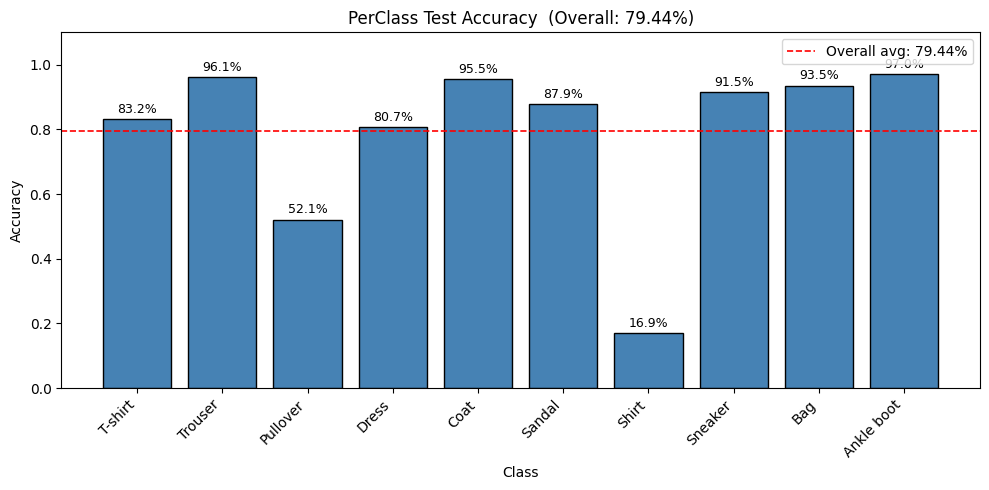

In [7]:
Y_test     = one_hot(y_test)
test_preds = softmax(X_test @ W).argmax(axis=1)
test_loss  = cross_entropy_loss(X_test, Y_test, W)
test_acc   = np.mean(test_preds == y_test)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

confusion     = np.zeros((C, C), dtype=int)
for true, pred in zip(y_test, test_preds):
    confusion[true, pred] += 1

per_class_acc = confusion.diagonal() / confusion.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, per_class_acc, color='steelblue', edgecolor='black')

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1.1)
ax.set_xlabel('Class')
ax.set_ylabel('Accuracy')
ax.set_title(f'PerClass Test Accuracy  (Overall: {test_acc*100:.2f}%)')
ax.axhline(y=test_acc, color='red', linestyle='--', linewidth=1.2, label=f'Overall avg: {test_acc*100:.2f}%')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()